# Derin Öğrenme Temelleri: Kavramlar, Karşılaştırmalar ve PyTorch Uygulaması

Bu notebook'ta şunları ele alacağız:
1. **Yapay Zeka (YZ / AI)**, **Makine Öğrenmesi (MO / ML)** ve **Derin Öğrenme (DO / DL)** kavramlarının tanımları ve ilişkileri
2. **Makine Öğrenmesi** ile **Derin Öğrenme** arasındaki farkları karşılaştıran bir tablo
3. Temel bir makine öğrenmesi denkleminin (**Lineer Regresyon**) PyTorch ile görselleştirilmesi ve adım adım açıklanması

---

## 1. Temel Kavramlar

### 1.1. Yapay Zeka (Artificial Intelligence - AI)

**Yapay Zeka**, insan zekâsını taklit eden sistemlerin genel adıdır. Bir bilgisayarın veya makinenin, görme, konuşma tanıma, karar verme ve dil çevirisi gibi genellikle insan zekâsı gerektiren görevleri yerine getirme yeteneğidir.

- **Örnek**: Satranç oynayan bir bot, sesli asistanlar (Siri, Alexa), öneri sistemleri (Netflix, Spotify).

### 1.2. Makine Öğrenmesi (Machine Learning - ML)

**Makine Öğrenmesi**, Yapay Zekanın bir *alt dalıdır*. Geleneksel programlamada biz kuralları yazarız; makine öğrenmesinde ise makineye çok sayıda örnek veri sunulur ve verilerden **istatistiksel kalıpları** ve **kuralları kendi öğrenmesi** sağlanır.

- **Örnek**: E-posta spam filtreleme, kredi risk analizi, ev fiyatı tahmini.

### 1.3. Derin Öğrenme (Deep Learning - DL)

**Derin Öğrenme**, Makine Öğrenmesinin bir *alt dalıdır*. İnsan beynindeki nöron yapısından esinlenen **Yapay Sinir Ağları (YSA)** kullanır. Geleneksel MO yöntemlerinin elle çıkarılan özellikler (feature extraction) gerektirdiği durumlarda, Derin Öğrenme modeli verinin **ham halinden** kendi özelliklerini otomatik olarak çıkarır.

- **Örnek**: Yüz tanıma, otonom araçlar, doğal dil işleme (ChatGPT), tıbbi görüntü analizi.

### Hiyerarşik İlişki



<p align="center">
  <img src="images/ai_ml_dl_hierarchy.png" alt="Yapay Zeka, Makine Öğrenmesi ve Derin Öğrenme arasındaki hiyerarşik ilişki." width="80%">
</p>

*Yapay Zeka, Makine Öğrenmesi ve Derin Öğrenme arasındaki hiyerarşik ilişki.*

## 2. Makine Öğrenmesi vs. Derin Öğrenme Karşılaştırması

Aşağıdaki tablo, iki yaklaşımı temel eksenlerde karşılaştırmaktadır:

| Özellik | Makine Öğrenmesi (ML) | Derin Öğrenme (DL) |
|:---|:---|:---|
| **Veri İhtiyacı** | Genellikle az veya orta ölçekli veri ile çalışabilir. | Çok büyük miktarda veri gerektirir (Big Data). |
| **Donanım** | Standart CPU'lar genellikle yeterlidir. | Yüksek paralel işlem gücü gerektirir (GPU / TPU). |
| **Özellik Çıkarımı** | İnsan uzmanları tarafından elle tanımlanır (feature engineering). | Model, verinin ham halinden kendi özelliklerini otomatik öğrenir. |
| **Yorumlanabilirlik** | Modeller genellikle daha kolay yorumlanır (örneğin karar ağaçları). | "Kara kutu" olarak nitelendirilir; iç işleyişi yorumlamak zordur. |
| **Eğitim Süresi** | Genellikle kısa veya orta sürelidir. | Büyük veri ve karmaşık mimariler nedeniyle uzun sürebilir. |
| **Problem Türü** | Yapılandırılmış veriler (tablo, sayısal veri) üzerinde çok başarılıdır. | Yapılandırılmamış veriler (görüntü, ses, metin) üzerinde üstündür. |
| **Algoritma Örnekleri** | Lineer Regresyon, SVM, Karar Ağaçları, Random Forest, K-Means. | CNN (Evrişimli Sinir Ağları), RNN, LSTM, Transformer'lar. |

<p align="center">
  <img src="images/feature_engineering_vs_deep_learning.png" alt="Geleneksel makine öğrenmesinde insan uzmanı tarafından özellik çıkarımı yapılırken, derin öğrenmede model ham veriden otomatik olarak özellikleri öğrenir." width="80%">
</p>

*Geleneksel makine öğrenmesinde  uzman tarafından özellik çıkarımı yapılırken, derin öğrenmede model ham veriden otomatik olarak özellikleri öğrenir.*

## 3. PyTorch ile Bir Makine Öğrenmesi Denkleminin Görselleştirilmesi

Bu bölümde, temel bir **Lineer Regresyon** denklemini ele alacağız. Lineer regresyon, sürekli bir çıktıyı tahmin etmek için kullanılan en temel makine öğrenmesi algoritmalarından biridir.

### Denklem

$y = Wx + b$

Burada:
- : Tahmin edilen çıktı (hedef değişken)
- : Girdi özelliği (bağımsız değişken)
- : Ağırlık (weight) — $'in $ üzerindeki etkisinin büyüklüğünü gösterir
- : Bias (sapma) — doğrunun y eksenini kestiği noktayı belirler

Makine öğrenmesinin amacı, veriye en iyi uyan $W$ ve $b$ değerlerini bulmaktır. Bunu PyTorch ile adım adım yapacağız.

---

In [ ]:
# Gerekli kütüphaneleri yüklüyoruz
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

print("PyTorch sürümü:", torch.__version__)
print("GPU kullanılabilir mi:", torch.cuda.is_available())

PyTorch sürümü: 2.10.0+cpu
GPU kullanılabilir mi: False


### Adım 1: Sentetik Veri Seti Oluşturma
Gerçek dünyadaki bir ilişkiyi taklit eden rastgele veriler üretelim. Gerçek değerlerimiz (ground truth)  = 2.0$ ve  = 1.0$ olsun. Veriye biraz gürültü (noise) ekleyelim.

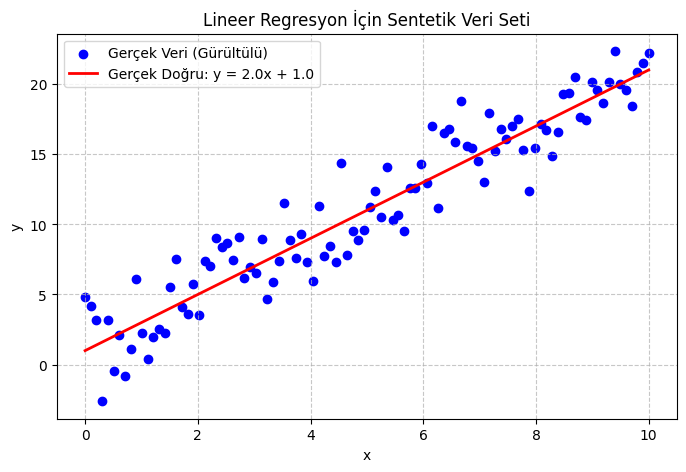

In [ ]:
# Rastgelelik için tohum ayarı
torch.manual_seed(42)

# Hiperparametreler
w_true = 2.0
b_true = 1.0
n_samples = 100

# Girdi verisi: 0 ile 10 arasında düzgün dağılmış 100 örnek
X = torch.linspace(0, 10, n_samples).unsqueeze(1)  # boyut: (100, 1)

# Gerçek denklem: y = 2x + 1 + gürültü
noise = torch.randn(n_samples, 1) * 2.0
y = w_true * X + b_true + noise

# Veriyi görselleştirelim
plt.figure(figsize=(8, 5))
plt.scatter(X.numpy(), y.numpy(), color="blue", label="Gerçek Veri (Gürültülü)")
plt.plot(X.numpy(), w_true * X.numpy() + b_true, color="red", linewidth=2, label=f"Gerçek Doğru: y = {w_true}x + {b_true}")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Lineer Regresyon İçin Sentetik Veri Seti")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

### Adım 2: Modelin Tanımlanması
PyTorch'ta  katmanı, denklemdeki $ (ağırlık) ve $ (bias) parametrelerini otomatik olarak içerir ve yönetir.

In [ ]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super(LinearRegressionModel, self).__init__()
        # Girdi boyutu 1, çıktı boyutu 1 olan lineer katman
        self.linear = nn.Linear(in_features=1, out_features=1)

    def forward(self, x):
        return self.linear(x)

# Modeli oluştur
model = LinearRegressionModel()

# Başlangıç parametrelerini yazdıralım
print("Başlangıç Ağırlığı (w):", model.linear.weight.item())
print("Başlangıç Bias'ı (b):", model.linear.bias.item())

Başlangıç Ağırlığı (w): 0.1563711166381836
Başlangıç Bias'ı (b): -0.8799213171005249


###
Adım 3: Kayıp Fonksiyonu ve Optimizasyon

Modelin tahminleri ile gerçek değerler arasındaki farkı ölçmek için **Ortalama Kare Hatası (Mean Squared Error - MSE)** kullanacağız.

$$MSE = \frac{1}{N} \sum_{i=1}^{N} (y_{tahmin} - y_{gerçek})^2$$

Parametreleri güncellemek için **Stokastik Gradyan İnişi (SGD)** optimizasyon algoritmasını kullanacağız.

In [ ]:
# Kayıp fonksiyonu: Ortalama Kare Hatası
criterion = nn.MSELoss()

# Optimizasyon algoritması: SGD (Öğrenme oranı 0.01)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

<p align="center">
  <img src="images/gradient_descent.png" alt="Gradyan inişi algoritması, kayıp fonksiyonunun en düşük olduğu noktaya doğru iteratif olarak ilerler." width="80%">
</p>

*Gradyan inişi algoritması, kayıp fonksiyonunun en düşük olduğu noktaya doğru iteratif olarak ilerler.*

### Adım 4: Eğitim Döngüsü (Training Loop)

Her bir iterasyonda (epoch):
1. Modelden tahmin alınır (forward pass).
2. Tahmin ile gerçek değer arasındaki hata hesaplanır (loss).
3. Gradyanlar hesaplanır (backward pass).
4. Optimizasyon algoritması parametreleri günceller (w ve b).

Eğitim sırasında belirli aralıklarla modelin durumunu görselleştireceğiz.

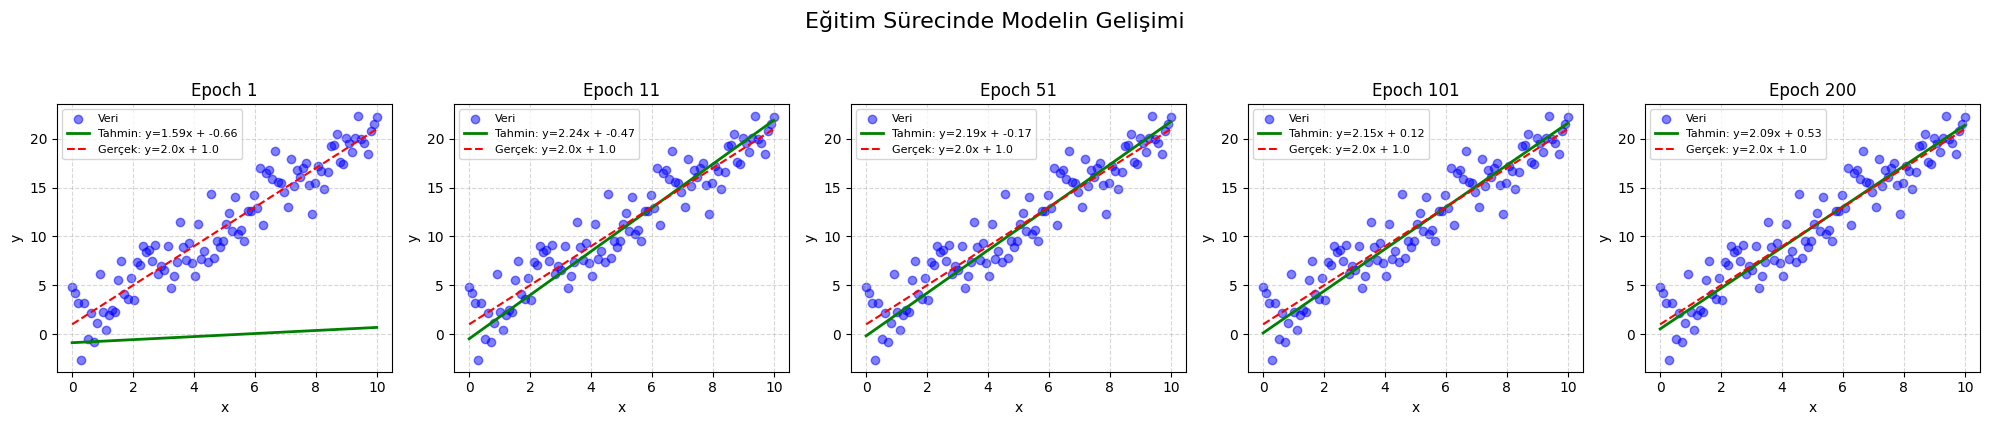

In [ ]:
epochs = 200
loss_history = []

# Görselleştirme için bazı epoch'ları seçelim
snapshot_epochs = [0, 10, 50, 100, 199]
fig, axes = plt.subplots(1, len(snapshot_epochs), figsize=(20, 4))
ax_idx = 0

for epoch in range(epochs):
    # 1. Forward Pass
    y_pred = model(X)

    # 2. Loss Hesaplama
    loss = criterion(y_pred, y)
    loss_history.append(loss.item())

    # 3. Geriye Doğru Yayılım (Backpropagation)
    optimizer.zero_grad()  # Önceki gradyanları sıfırla
    loss.backward()        # Gradyanları hesapla

    # 4. Parametre Güncelleme
    optimizer.step()       # w ve b'yi güncelle

    # Görselleştirme anlık görüntüleri
    if epoch in snapshot_epochs:
        ax = axes[ax_idx]
        ax.scatter(X.numpy(), y.numpy(), color="blue", alpha=0.5, label="Veri")

        # Mevcut tahmin edilen doğruyu çiz
        current_w = model.linear.weight.item()
        current_b = model.linear.bias.item()
        ax.plot(X.numpy(), y_pred.detach().numpy(), color="green", linewidth=2, label=f"Tahmin: y={current_w:.2f}x + {current_b:.2f}")

        # Gerçek doğruyu de çiz (referans olarak)
        ax.plot(X.numpy(), w_true * X.numpy() + b_true, color="red", linestyle="--", linewidth=1.5, label=f"Gerçek: y={w_true}x + {b_true}")

        ax.set_title(f"Epoch {epoch + 1}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.legend(fontsize=8)
        ax.grid(True, linestyle="--", alpha=0.5)
        ax_idx += 1

plt.suptitle("Eğitim Sürecinde Modelin Gelişimi", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

### Adım 5: Sonuçların Değerlendirilmesi
Eğitim tamamlandıktan sonra, modelin öğrendiği nihai $ ve $ değerlerini gerçek değerlerle karşılaştıralım. Ayrıca kayıp fonksiyonunun zaman içinde nasıl düştüğünü inceleyelim.

===== EĞİTİM SONUÇLARI =====
Gerçek Ağırlık (w):      2.0000
Öğrenilen Ağırlık (w):   2.0851
Gerçek Bias (b):         1.0000
Öğrenilen Bias (b):      0.5340


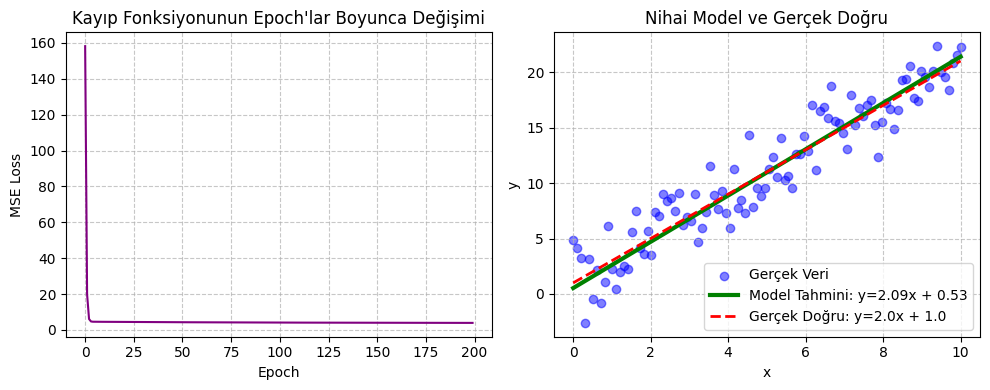

In [ ]:
# Nihai parametreler
learned_w = model.linear.weight.item()
learned_b = model.linear.bias.item()

print("===== EĞİTİM SONUÇLARI =====")
print(f"Gerçek Ağırlık (w):      {w_true:.4f}")
print(f"Öğrenilen Ağırlık (w):   {learned_w:.4f}")
print(f"Gerçek Bias (b):         {b_true:.4f}")
print(f"Öğrenilen Bias (b):      {learned_b:.4f}")
print("=============================")

# Kayıp fonksiyonunun azalışını görselleştirme
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(loss_history, color="purple")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Kayıp Fonksiyonunun Epoch'lar Boyunca Değişimi")
plt.grid(True, linestyle="--", alpha=0.7)

plt.subplot(1, 2, 2)
plt.scatter(X.numpy(), y.numpy(), color="blue", alpha=0.5, label="Gerçek Veri")
plt.plot(X.numpy(), learned_w * X.numpy() + learned_b, color="green", linewidth=3, label=f"Model Tahmini: y={learned_w:.2f}x + {learned_b:.2f}")
plt.plot(X.numpy(), w_true * X.numpy() + b_true, color="red", linestyle="--", linewidth=2, label=f"Gerçek Doğru: y={w_true}x + {b_true}")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Nihai Model ve Gerçek Doğru")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

## 5. Lojistik Regresyon ve Basit Sinir Ağı (MLP)

Lineer regresyon sürekli değerler tahmin ederken, gerçek dünyadaki birçok problem **sınıflandırma** gerektirir. Bu bölümde:
- **Lojistik Regresyon**: İkili sınıflandırma problemlerinin temel taşı.
- **Basit Sinir Ağı (MLP - Multilayer Perceptron)**: Doğrusal olarak ayrılamayan verileri modelleyebilen, gizli katmanlara sahip yapı.

Aynı sentetik veri seti üzerinde her iki modeli de eğitip **karar sınırlarını** karşılaştıracağız.

### 5.1. Lojistik Regresyon Nedir?

Lojistik regresyon, bir girdinin belirli bir sınıfa ait olma **olasılığını** tahmin eden istatistiksel bir modeldir. Çıktıyı [0, 1] aralığına sıkıştırmak için **Sigmoid** aktivasyon fonksiyonu kullanılır.

**Adımlar:**
1. Lineer kombinasyon hesaplanır: $z = w_1x_1 + w_2x_2 + b$
2. Sigmoid fonksiyonu uygulanır: $\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$
3. Eşik değeri (threshold, genellikle 0.5) ile sınıf atanır.

**Kayıp Fonksiyonu:** Binary Cross Entropy (BCE)
$$ \mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right] $$

**Kullanım Alanları:**
- E-posta spam tespiti (spam / spam değil)
- Tıbbi teşhis (hasta / sağlıklı)
- Müşteri kaybı (churn) tahmini
- Kredi onayı (onaylanır / reddedilir)

<p align="center">
  <img src="images/sigmoid_function.png" alt="Sigmoid fonksiyonu, herhangi bir gerçek sayıyı 0 ile 1 arasına sıkıştırarak olasılık tahmini yapmayı sağlar." width="80%">
</p>

*Sigmoid fonksiyonu, herhangi bir gerçek sayıyı 0 ile 1 arasına sıkıştırarak olasılık tahmini yapmayı sağlar.*

### 5.2. Basit Sinir Ağı (MLP) Nedir?

**Multilayer Perceptron (MLP)**, en az bir gizli katman (hidden layer) içeren bir yapay sinir ağı mimarisidir. Lojistik regresyon aslında gizli katmanı olmayan, girdiyi doğrudan çıktıya bağlayan özel bir sinir ağıdır.

**Temel Farklar:**
- **Lojistik Regresyon**: Girdi ile çıktı arasında sadece doğrusal bir ilişki öğrenebilir. Doğrusal olarak ayrılamayan verilerde (örn. hilal şekilli veri) başarısızdır.
- **MLP**: Gizli katmanlar ve doğrusal olmayan aktivasyon fonksiyonları (örneğin **ReLU**, **Tanh**) sayesinde karmaşık, eğri karar sınırları öğrenebilir.

**Mimari:**
```
Girdi Katmanı  ->  Gizli Katman (ReLU)  ->  Çıktı Katmanı (Sigmoid)
   (2 nöron)          (16 nöron)                (1 nöron)
```

**Kullanım Alanları:**
- Karmaşık görüntü sınıflandırma (derin versiyonları: CNN)
- Doğal dil işleme ve duygu analizi (derin versiyonları: RNN, Transformer)
- Ses tanıma ve sentezi
- Oyun ve robotik kontrol stratejileri

<p align="center">
  <img src="images/neural_network_architecture.png" alt="Çok Katmanlı Algılayıcı (MLP) mimarisi: girdi katmanı, gizli katman (ReLU) ve çıktı katmanından (Sigmoid) oluşur." width="80%">
</p>

*Çok Katmanlı Algılayıcı (MLP) mimarisi: girdi katmanı, gizli katman (ReLU) ve çıktı katmanından (Sigmoid) oluşur.*

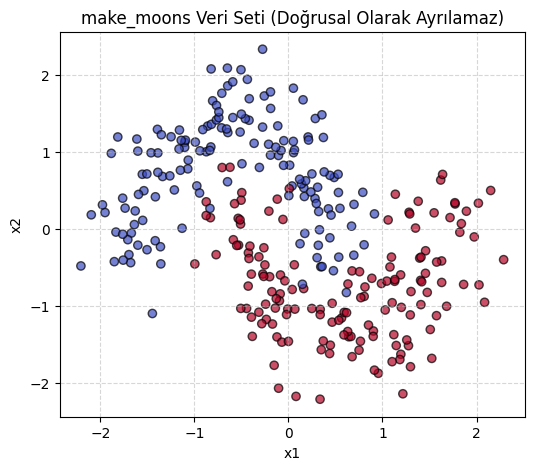

In [ ]:
# Lojistik regresyon ve sinir ağı için gerekli ek kütüphaneler
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

# Hilal şeklinde, doğrusal olarak ayrılamayan 2 sınıflı veri seti oluşturuyoruz
X_moon, y_moon = make_moons(n_samples=300, noise=0.2, random_state=42)

# Özellikleri standartlaştırma (ortalama=0, std=1)
scaler = StandardScaler()
X_moon = scaler.fit_transform(X_moon)

# PyTorch tensorlerine dönüştürme
X_tensor = torch.FloatTensor(X_moon)
y_tensor = torch.FloatTensor(y_moon).unsqueeze(1)  # boyut: (300, 1)

# Veri yükleyici (DataLoader) oluşturma
dataset = TensorDataset(X_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Veriyi görselleştirelim
plt.figure(figsize=(6, 5))
plt.scatter(X_moon[:, 0], X_moon[:, 1], c=y_moon, cmap='coolwarm', edgecolors='k', alpha=0.7)
plt.title('make_moons Veri Seti (Doğrusal Olarak Ayrılamaz)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### Karar Sınırı Çizim Fonksiyonu
İki modelin öğrendiği sınırı görselleştirmek için ortak bir fonksiyon tanımlayalım.

In [ ]:
def plot_decision_boundary(model, X, y, title, ax=None):
    if ax is None:
        plt.figure(figsize=(6, 5))
        ax = plt.gca()

    # Izgara oluştur
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = torch.meshgrid(
        torch.linspace(x_min, x_max, 200),
        torch.linspace(y_min, y_max, 200),
        indexing='ij'
    )
    grid = torch.cat([xx.reshape(-1, 1), yy.reshape(-1, 1)], dim=1)

    # Model tahminleri
    model.eval()
    with torch.no_grad():
        preds = model(grid).reshape(xx.shape).numpy()

    # Kontur çizimi
    ax.contourf(xx.numpy(), yy.numpy(), preds, levels=50, cmap='coolwarm', alpha=0.4)
    ax.contour(xx.numpy(), yy.numpy(), preds, levels=[0.5], colors='black', linewidths=2)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
    ax.set_title(title)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.grid(True, linestyle='--', alpha=0.5)

### 5.3. Lojistik Regresyon Modeli ve Eğitimi

In [ ]:
class LogisticRegressionModel(nn.Module):
    def __init__(self):
        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(2, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))

# Model, kayıp fonksiyonu ve optimizer
log_model = LogisticRegressionModel()
criterion_log = nn.BCELoss()
optimizer_log = torch.optim.SGD(log_model.parameters(), lr=0.1)

epochs = 500
loss_history_log = []

for epoch in range(epochs):
    epoch_loss = 0
    for batch_X, batch_y in dataloader:
        optimizer_log.zero_grad()
        outputs = log_model(batch_X)
        loss = criterion_log(outputs, batch_y)
        loss.backward()
        optimizer_log.step()
        epoch_loss += loss.item()
    loss_history_log.append(epoch_loss / len(dataloader))

print(f"Lojistik Regresyon - Son Epoch Kayıp: {loss_history_log[-1]:.4f}")

Lojistik Regresyon - Son Epoch Kayıp: 0.3095


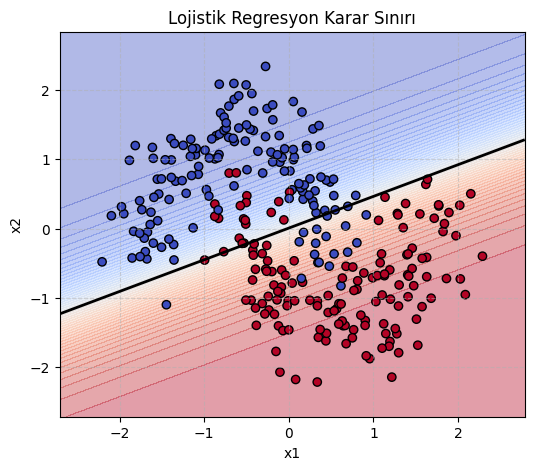

In [ ]:
# Lojistik Regresyon karar sınırını çizelim
plot_decision_boundary(log_model, X_moon, y_moon, 'Lojistik Regresyon Karar Sınırı')
plt.show()

> **Gözlem:** Lojistik regresyon sadece doğrusal bir karar sınırı çizebildiği için, hilal şekilli bu veri setinde iki sınıfı tam olarak ayıramıyor. Bu, modelin **underfitting** (yetersiz öğrenme) yaptığının bir işareti.

### 5.4. Basit Sinir Ağı (MLP) Modeli ve Eğitimi

In [ ]:
class SimpleNN(nn.Module):
    def __init__(self, hidden_dim=16):
        super(SimpleNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# Model, kayıp fonksiyonu ve optimizer
nn_model = SimpleNN(hidden_dim=16)
criterion_nn = nn.BCELoss()
optimizer_nn = torch.optim.Adam(nn_model.parameters(), lr=0.01)

loss_history_nn = []

for epoch in range(epochs):
    epoch_loss = 0
    for batch_X, batch_y in dataloader:
        optimizer_nn.zero_grad()
        outputs = nn_model(batch_X)
        loss = criterion_nn(outputs, batch_y)
        loss.backward()
        optimizer_nn.step()
        epoch_loss += loss.item()
    loss_history_nn.append(epoch_loss / len(dataloader))

print(f"Basit Sinir Ağı (MLP) - Son Epoch Kayıp: {loss_history_nn[-1]:.4f}")

Basit Sinir Ağı (MLP) - Son Epoch Kayıp: 0.0497


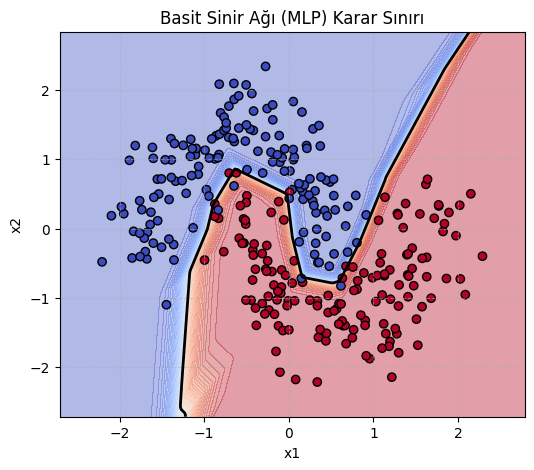

In [ ]:
# MLP karar sınırını çizelim
plot_decision_boundary(nn_model, X_moon, y_moon, 'Basit Sinir Ağı (MLP) Karar Sınırı')
plt.show()

> **Gözlem:** Sinir ağının gizli katmanı ve ReLU aktivasyonu sayesinde model, verinin karmaşık, eğri yapısını öğrenerek iki sınıfı neredeyse mükemmel şekilde ayırabiliyor.

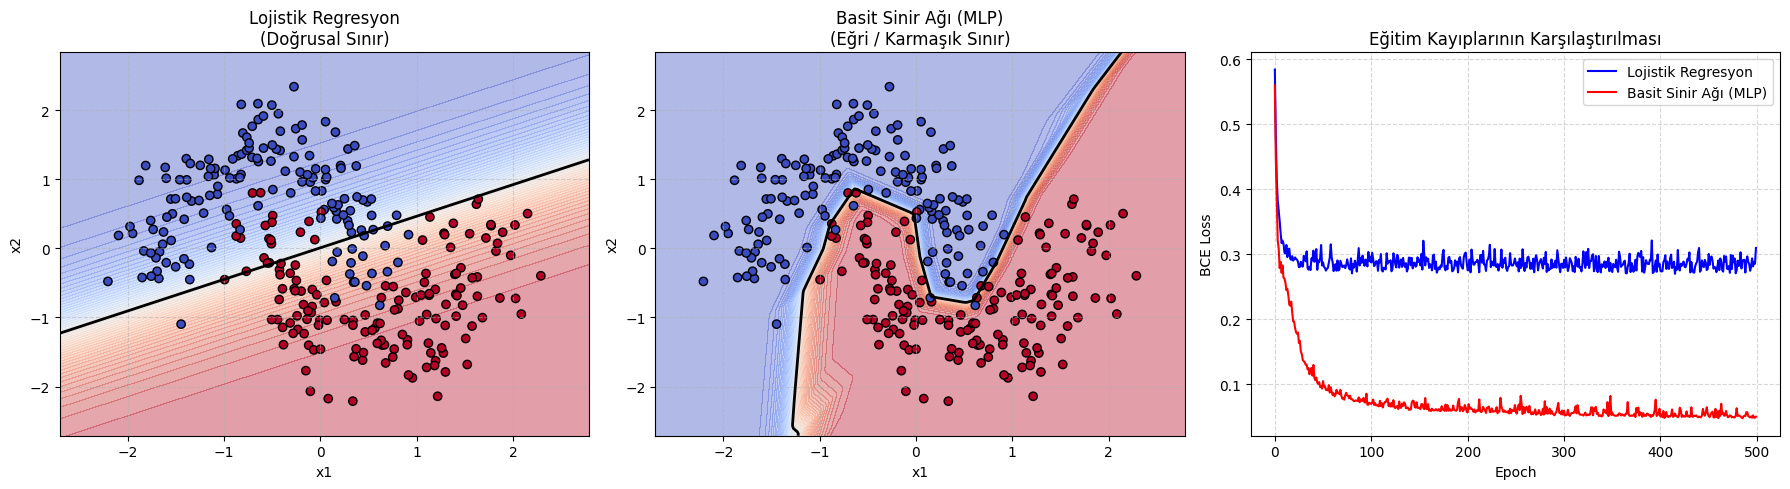

In [ ]:
# İki modelin karar sınırlarını ve kayıp eğrilerini yan yana karşılaştırma
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Lojistik Regresyon karar sınırı
plot_decision_boundary(log_model, X_moon, y_moon, 'Lojistik Regresyon\n(Doğrusal Sınır)', ax=axes[0])

# MLP karar sınırı
plot_decision_boundary(nn_model, X_moon, y_moon, 'Basit Sinir Ağı (MLP)\n(Eğri / Karmaşık Sınır)', ax=axes[1])

# Kayıp eğrileri karşılaştırması
axes[2].plot(loss_history_log, label='Lojistik Regresyon', color='blue')
axes[2].plot(loss_history_nn, label='Basit Sinir Ağı (MLP)', color='red')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('BCE Loss')
axes[2].set_title('Eğitim Kayıplarının Karşılaştırılması')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 6. Genel Sonuç ve Özet

Bu notebook'ta şunları öğrendik:

1. **Hiyerarşi**: Derin Öğrenme ⊂ Makine Öğrenmesi ⊂ Yapay Zeka.
2. **Farklar**: Makine öğrenmesi daha az veriyle, yapılandırılmış verilerde ve yorumlanabilir modellerle çalışırken; derin öğrenme büyük veri, karmaşık yapılandırılmamış veri (görüntü, ses, metin) ve yüksek hesaplama gücü gerektirir.
3. **PyTorch ile Lineer Regresyon**: Temel denklem $y = wx + b$'nin parametrelerinin, bir kayıp fonksiyonu ve gradyan inişi kullanılarak veriden nasıl öğrenildiğini adım adım görselleştirdik.
4. **Lojistik Regresyon vs. Sinir Ağı**:
   - Lojistik regresyon doğrusal sınırlar çizer ve basit sınıflandırma problemleri için idealdir.
   - Basit bir sinir ağı (MLP) ise gizli katmanlar sayesinde doğrusal olmayan karmaşık desenleri öğrenebilir.
   - `make_moons` örneğinde, lojistik regresyonun başarısız olduğu doğrusal olarak ayrılamayan veriyi, MLP'nin başarıyla ayırdığını gözlemledik.

Bu temel anlayış, daha karmaşık sinir ağı mimarilerine (CNN, RNN, Transformer) geçiş için sağlam bir zemin oluşturur.